# Sentiment Analysis on Twitter Data

## Objective
The objective of this project is to perform sentiment analysis on textual data (tweets) using Natural Language Processing (NLP) techniques. The goal is to classify text into positive or negative sentiments.

## Tools & Technologies Used
- Python
- Pandas, NumPy
- NLTK (Natural Language Processing)
- Scikit-learn
- Matplotlib, Seaborn

## Dataset
The dataset used is a Twitter Sentiment dataset containing labeled tweets.

In [1]:
# Install required libraries (run only once)
!pip install pandas numpy scikit-learn nltk matplotlib seaborn

## Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Download NLTK Stopwords

In [38]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\boyin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
zip_path = r"C:\Users\boyin\Downloads\archive (2)\training.1600000.processed.noemoticon.csv"

## Load Dataset

In [5]:
import pandas as pd

file_path = r"C:\Users\boyin\Downloads\archive (2)\training.1600000.processed.noemoticon.csv"

df = pd.read_csv(file_path, encoding='latin1', header=None)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


## Assign Column Names

In [6]:
df.columns = ['target', 'id', 'date', 'flag', 'user', 'text']

## Select Relevant Columns

In [7]:
df = df[['target', 'text']]

## Convert Target Labels (0 = Negative, 1 = Positive)

In [8]:
df['target'] = df['target'].replace(4, 1)

## Data Preview

In [9]:
df.head()

,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [10]:
df['target'].value_counts()

target
0    800000
1    800000
Name: count, dtype: int64

## Text Preprocessing and Cleaning

In [20]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Remove non-letters
    text = re.sub('[^a-zA-Z]', ' ', text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Split into words
    words = text.split()
    
    # Remove stopwords and apply stemming
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    
    # Join words back
    return ' '.join(words)

In [21]:
df['cleaned_text'] = df['text'].apply(clean_text)

In [22]:
df[['text', 'cleaned_text']].head()

,text,cleaned_text
541200,@chrishasboobs AHHH I HOPE YOUR OK!!!,chrishasboob ahhh hope ok
750,"@misstoriblack cool , i have no tweet apps fo...",misstoriblack cool tweet app razr
766711,@TiannaChaos i know just family drama. its la...,tiannachao know famili drama lame hey next tim...
285055,School email won't open and I have geography ...,school email open geographi stuff revis stupid...
705995,upper airways problem,upper airway problem


## Reduce Dataset Size (to avoid memory issues)

In [23]:
df = df.sample(n=50000, random_state=42)

## Feature Extraction using TF-IDF

In [40]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['cleaned_text']).toarray()
y = df['target']

In [25]:
print(X.shape)
print(y.shape)

(50000, 5000)
(50000,)


## Split Data into Training and Testing Sets

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
print(X_train.shape)
print(X_test.shape)

(40000, 5000)
(10000, 5000)


## Train Logistic Regression Model

In [28]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


## Model Evaluation

In [29]:
y_pred = model.predict(X_test)

In [30]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7508


In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.72      0.74      5016
           1       0.74      0.78      0.76      4984

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000



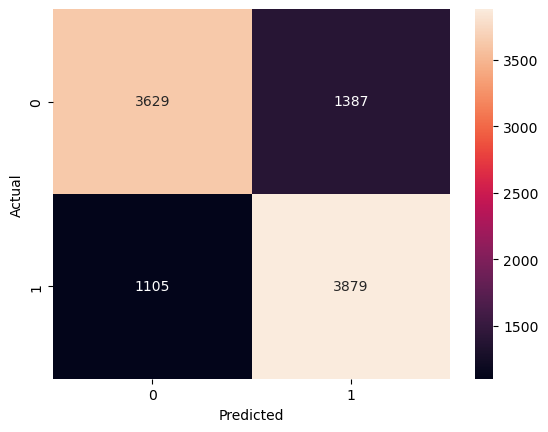

In [32]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Test Model with Custom Input

In [35]:
def predict_sentiment(text):
    text = clean_text(text)
    vector = vectorizer.transform([text]).toarray()
    prediction = model.predict(vector)
    
    return "Positive 😊" if prediction[0] == 1 else "Negative 😡"

In [36]:
print(predict_sentiment("I love this product!"))
print(predict_sentiment("This is the worst experience ever"))

Positive 😊
Negative 😡


## Insights

- Text data was cleaned using NLP techniques like stopword removal and stemming.
- TF-IDF was used for feature extraction.
- Logistic Regression performed well for binary classification.
- The model achieved good accuracy on test data.
- Dataset reduction helped in handling memory efficiently.

## Conclusion

This project demonstrates how sentiment analysis can be performed using machine learning and NLP techniques. It can be applied in areas like social media monitoring, customer feedback analysis, and product review systems.